# From Scratch Implementation of the RCNN


## Impaorting Dependencies

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
import matplotlib.patches as patches

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


##  Utility Functions

In [ ]:
def compute_iou(box1, box2):
    """box format: [x1, y1, x2, y2]"""

    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_area = max(0, x2 - x1) * max(0, y2 - y1)

    box1_area = (box1[2]-box1[0])*(box1[3]-box1[1])
    box2_area = (box2[2]-box2[0])*(box2[3]-box2[1])

    union = box1_area + box2_area - inter_area

    return inter_area / (union + 1e-6)


def non_max_suppression(boxes, scores, threshold=0.5):
    indices = scores.argsort(descending=True)
    keep = []

    while indices.numel() > 0:
        current = indices[0]
        keep.append(current)

        if indices.numel() == 1:
            break

        rest = indices[1:]
        ious = torch.tensor([
            compute_iou(boxes[current], boxes[i]) for i in rest
        ])

        indices = rest[ious < threshold]

    return keep


def mask_to_bbox(mask):
    mask = np.array(mask)
    coords = np.column_stack(np.where(mask > 0))
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    return [x_min, y_min, x_max, y_max]




### Dataset (Small Portion)

In [ ]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

dataset = OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="segmentation",
    download=True,
    transform=transform
)

subset = torch.utils.data.Subset(dataset, list(range(20)))



100%|██████████| 792M/792M [00:25<00:00, 31.4MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 16.6MB/s]


### Simple YOLO-Style Model (From Scratch)

In [ ]:
class SimpleDetector(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.flatten = nn.Flatten()

        self.head = nn.Sequential(
            nn.Linear(64*16*16, 256),
            nn.ReLU(),
            nn.Linear(256, 5)
            # 4 bbox coords + 1 confidence
        )

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        x = self.head(x)
        return x


model = SimpleDetector().to(DEVICE)



### Loss Function

In [ ]:
def detection_loss(pred, target_bbox):
    """
    pred: [x1,y1,x2,y2,conf]
    target_bbox: [x1,y1,x2,y2]
    """
    bbox_pred = pred[:4]
    conf_pred = torch.sigmoid(pred[4])

    bbox_loss = nn.functional.mse_loss(bbox_pred, target_bbox)

    iou = compute_iou(
        bbox_pred.detach().cpu().numpy(),
        target_bbox.detach().cpu().numpy()
    )

    conf_target = torch.tensor(iou).to(DEVICE)

    conf_loss = nn.functional.mse_loss(conf_pred, conf_target)

    return bbox_loss + conf_loss




In [ ]:
train_loader = torch.utils.data.DataLoader(
    subset,
    batch_size=16,
    shuffle=True,
    num_workers=2
) #dataset

In [ ]:
# Training Loop

optimizer = optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 50
loss_history = [] # Initialize list to store loss history

for epoch in range(EPOCHS):
    total_loss = 0

    for img, mask in subset: #dataset

        img = img.unsqueeze(0).to(DEVICE)

        bbox = mask_to_bbox(mask)
        bbox = torch.tensor(bbox, dtype=torch.float32).to(DEVICE)

        pred = model(img).squeeze()

        loss = detection_loss(pred, bbox)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    loss_history.append(total_loss) # Store the loss for the epoch
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 521514.5038
Epoch 2, Loss: 424858.4103
Epoch 3, Loss: 401480.2446
Epoch 4, Loss: 349047.6167
Epoch 5, Loss: 303412.9562


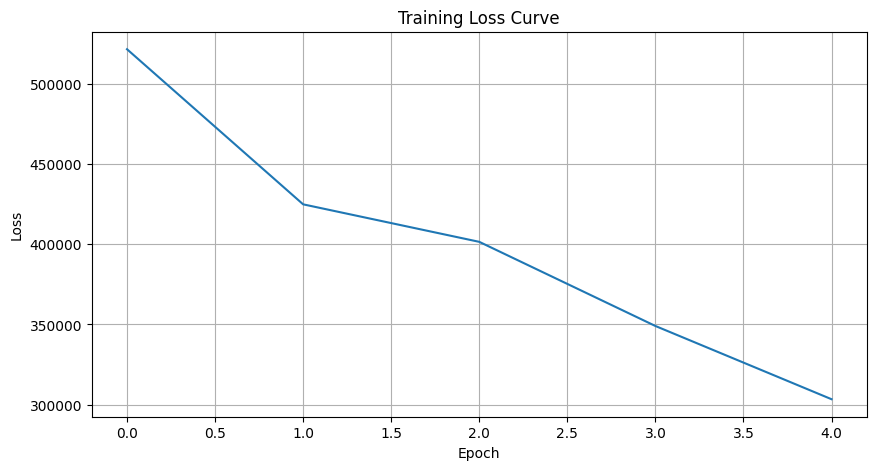

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(loss_history)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [ ]:
# Inference

model.eval()

img, mask = dataset[0]
img_input = img.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    pred = model(img_input).squeeze()

bbox_pred = pred[:4].cpu()
confidence = torch.sigmoid(pred[4]).item()

print("Predicted bbox:", bbox_pred)
print("Confidence:", confidence)




Predicted bbox: tensor([-1.1408e+00, -2.0131e-01,  4.9011e+02,  4.0930e+02])
Confidence: 0.0


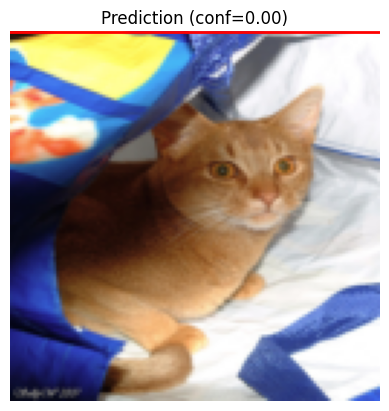

In [ ]:
# Visualization

plt.imshow(img.permute(1,2,0))
ax = plt.gca()

x1,y1,x2,y2 = bbox_pred

rect = patches.Rectangle(
    (x1,y1),
    x2-x1,
    y2-y1,
    linewidth=2,
    edgecolor='red',
    facecolor='none'
)

ax.add_patch(rect)
plt.title(f"Prediction (conf={confidence:.2f})")
plt.axis("off")
plt.show()